In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import re
import warnings
warnings.filterwarnings("ignore")

# Load the dataset
data = pd.read_csv('recipes.csv')  # Replace with your actual file path

Data Exploration

In [3]:
print("Dataset Shape:", data.shape)

Dataset Shape: (1090, 15)


In [4]:
print("\nColumns:", data.columns.tolist())


Columns: ['Unnamed: 0', 'recipe_name', 'prep_time', 'cook_time', 'total_time', 'servings', 'yield', 'ingredients', 'directions', 'rating', 'url', 'cuisine_path', 'nutrition', 'timing', 'img_src']


In [5]:
print("\nData Types:\n", data.dtypes)


Data Types:
 Unnamed: 0        int64
recipe_name      object
prep_time        object
cook_time        object
total_time       object
servings          int64
yield            object
ingredients      object
directions       object
rating          float64
url              object
cuisine_path     object
nutrition        object
timing           object
img_src          object
dtype: object


In [6]:
print("\nMissing Values:\n", data.isnull().sum())


Missing Values:
 Unnamed: 0        0
recipe_name       0
prep_time        51
cook_time       308
total_time       45
servings          0
yield           211
ingredients       0
directions        0
rating            0
url               0
cuisine_path      0
nutrition         0
timing            0
img_src           0
dtype: int64


In [7]:
data.head()

,Unnamed: 0,recipe_name,prep_time,cook_time,total_time,servings,yield,ingredients,directions,rating,url,cuisine_path,nutrition,timing,img_src
0,0,Apple-Cranberry Crostada,NaN,NaN,NaN,8,6 to 8 - servings,"3 tablespoons butter, 2 pounds Granny Smith ap...",Heat butter in a large skillet over medium-hig...,4.4,https://www.allrecipes.com/recipe/76931/apple-...,/Desserts/Fruit Desserts/Apple Dessert Recipes/,"Total Fat 18g 23%, Saturated Fat 7g 34%, Chole...","Servings: 8, Yield: 6 to 8 - servings",https://www.allrecipes.com/thmb/Tf1wH73bfH6Oql...
1,1,Apple Pie by Grandma Ople,30 mins,1 hrs,1 hrs 30 mins,8,1 9-inch pie,"8 small Granny Smith apples, or as needed, ½ c...","Peel and core apples, then thinly slice. Set a...",4.8,https://www.allrecipes.com/recipe/12682/apple-...,/Desserts/Pies/Apple Pie Recipes/,"Total Fat 19g 24%, Saturated Fat 9g 46%, Chole...","Prep Time: 30 mins, Cook Time: 1 hrs, Total Ti...",https://www.allrecipes.com/thmb/1I95oiTGz6aEpu...
2,2,Sarah's Homemade Applesauce,10 mins,15 mins,25 mins,4,NaN,"4 apples - peeled, cored and chopped, ¾ cup w...","Combine apples, water, sugar, and cinnamon in ...",4.8,https://www.allrecipes.com/recipe/51301/sarahs...,/Side Dish/Applesauce Recipes/,"Total Fat 0g 0%, Sodium 3mg 0%, Total Carbohyd...","Prep Time: 10 mins, Cook Time: 15 mins, Total ...",https://www.allrecipes.com/thmb/VY5d0tZHB8xz6y...
3,3,Apple Crisp,30 mins,45 mins,1 hrs 15 mins,12,1 9x13-inch pan,"10 cups all-purpose apples, peeled, cored and ...",Preheat the oven to 350 degrees F (175 degrees...,4.7,https://www.allrecipes.com/recipe/12409/apple-...,/Desserts/Crisps and Crumbles Recipes/Apple Cr...,"Total Fat 8g 11%, Saturated Fat 5g 25%, Choles...","Prep Time: 30 mins, Cook Time: 45 mins, Total ...",https://www.allrecipes.com/thmb/uAzhPOh86PfR-N...
4,4,Apple Pie Filling,20 mins,20 mins,2 hrs 40 mins,40,5 9-inch pies,"18 cups thinly sliced apples, 3 tablespoons le...",Toss apples with lemon juice in a large bowl a...,4.7,https://www.allrecipes.com/recipe/12681/apple-...,/Desserts/Pies/Apple Pie Recipes/,"Total Fat 0g 0%, Sodium 61mg 3%, Total Carbohy...","Prep Time: 20 mins, Cook Time: 20 mins, Additi...",https://www.allrecipes.com/thmb/c0bbYaS1V_mTt_...


Data Cleaning

In [8]:
# Create a copy for cleaning
df_clean = data.copy()

In [9]:
# Remove unnecessary columns
cols_to_drop = ['url', 'img_src', 'cuisine_path', 'nutrition', 'timing']
df_clean.drop(columns=[col for col in cols_to_drop if col in df_clean.columns], inplace=True)

In [10]:
# Handle missing values
print("Missing values before cleaning:")
print(df_clean.isnull().sum())

Missing values before cleaning:
Unnamed: 0       0
recipe_name      0
prep_time       51
cook_time      308
total_time      45
servings         0
yield          211
ingredients      0
directions       0
rating           0
dtype: int64


In [11]:
# Fill missing numerical values
numerical_cols = ['prep_time', 'cook_time', 'total_time', 'servings', 'rating']
for col in numerical_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [12]:
# Fill missing text values
text_cols = ['ingredients', 'directions', 'yield']
for col in text_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('')

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())


Missing values after cleaning:
Unnamed: 0        0
recipe_name       0
prep_time      1090
cook_time      1090
total_time     1090
servings          0
yield             0
ingredients       0
directions        0
rating            0
dtype: int64


 Feature Engineering for Ingredients

In [13]:
def preprocess_ingredients(ingredients_text):
    """Clean and preprocess ingredients text"""
    if pd.isna(ingredients_text):
        return ""

    # Remove measurements and quantities
    ingredients_text = re.sub(r'\d+\s*\w*\s*', '', ingredients_text)  # Remove numbers
    ingredients_text = re.sub(r'[Â¼Â½Â¾]', '', ingredients_text)  # Remove special fractions
    ingredients_text = re.sub(r'[\(\)\[\]]', '', ingredients_text)  # Remove brackets
    ingredients_text = re.sub(r'\s+', ' ', ingredients_text)  # Remove extra spaces

    # Convert to lowercase
    ingredients_text = ingredients_text.lower()

    return ingredients_text.strip()

# Apply preprocessing
df_clean['cleaned_ingredients'] = df_clean['ingredients'].apply(preprocess_ingredients)

# Extract unique ingredients for analysis
def extract_ingredient_list(ingredients_text):
    """Extract individual ingredients from text"""
    ingredients = []
    for item in ingredients_text.split(','):
        item = item.strip()
        if item and len(item) > 2:  # Filter out very short items
            ingredients.append(item)
    return ingredients

df_clean['ingredient_list'] = df_clean['cleaned_ingredients'].apply(extract_ingredient_list)

# Create a set of all unique ingredients
all_ingredients = set()
for ingredients in df_clean['ingredient_list']:
    all_ingredients.update(ingredients)

print(f"Total unique ingredients: {len(all_ingredients)}")
print(f"Sample ingredients: {list(all_ingredients)[:10]}")

Total unique ingredients: 2706
Sample ingredients: ['and cut into dice', 'very ripe bananas', 'garlic powder', 'figs', 'package country-style pork ribs', 'friendship fruit starter', 'ground cayenne pepper', 'pepper - cored', 'bags fresh cranberries', 'orange-fleshed sweet potato']


Data Analysis and Visualization

In [14]:
# Set up visualization style
plt.style.use('dark_background')
sns.set_palette("husl")

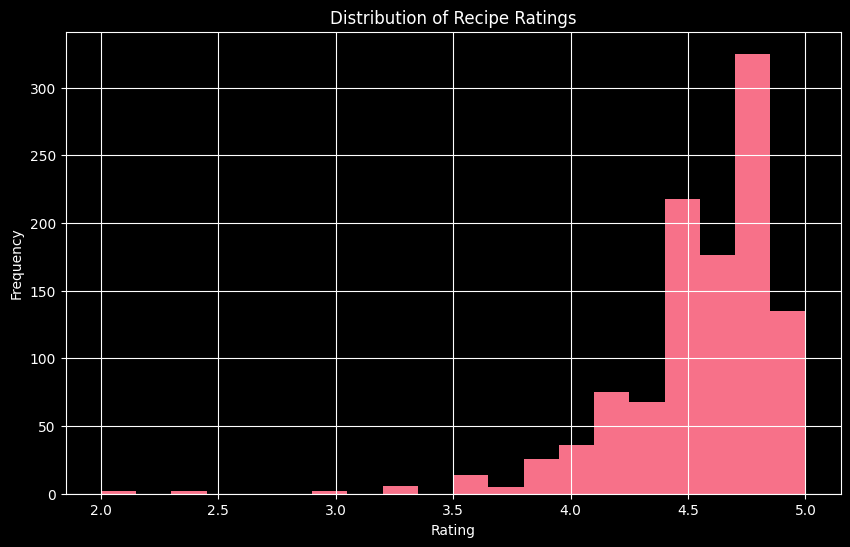

In [17]:
# Rating distribution
if 'rating' in df_clean.columns:
    plt.figure(figsize=(10, 6))
    df_clean['rating'].hist(bins=20)
    plt.title('Distribution of Recipe Ratings')
    plt.xlabel('Rating')
    plt.ylabel('Frequency')
    plt.show()

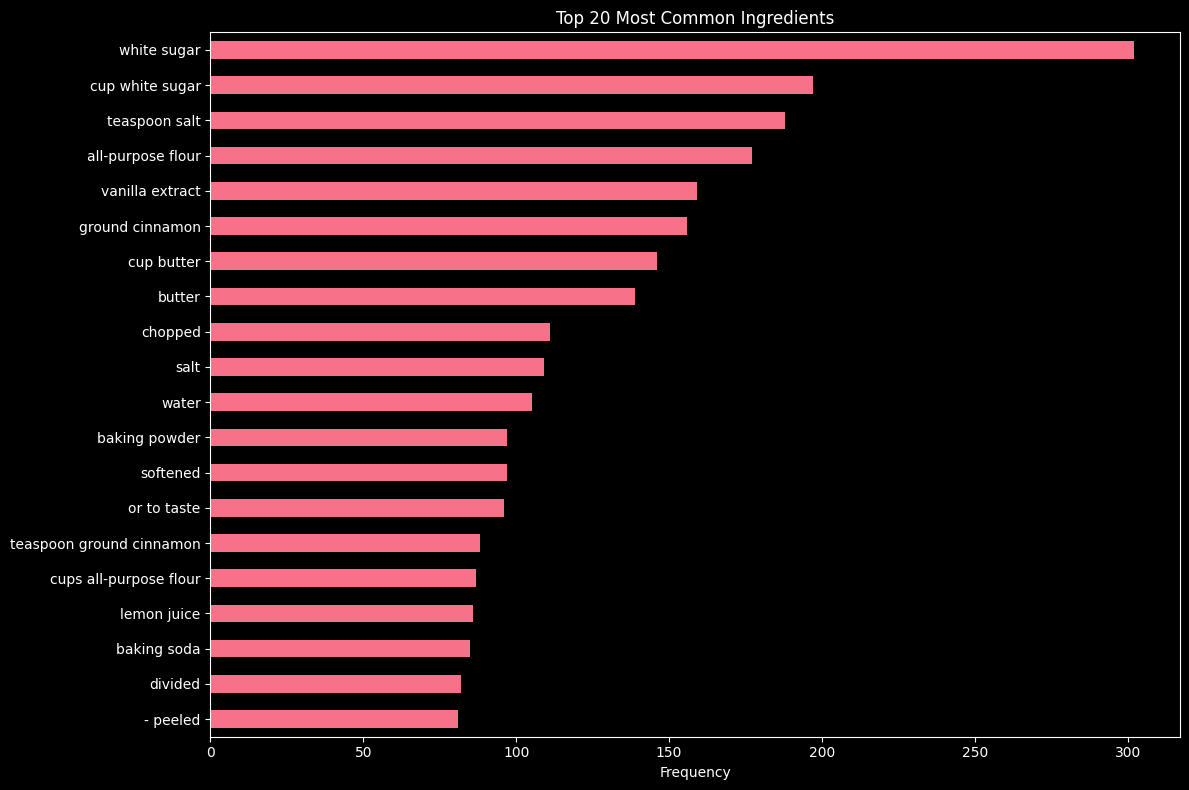

In [18]:
# 3. Most common ingredients
# Flatten all ingredient lists
all_ingredients_flat = []
for ingredients in df_clean['ingredient_list']:
    all_ingredients_flat.extend(ingredients)

ingredient_counts = pd.Series(all_ingredients_flat).value_counts().head(20)

plt.figure(figsize=(12, 8))
ingredient_counts.plot(kind='barh')
plt.title('Top 20 Most Common Ingredients')
plt.xlabel('Frequency')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Build Recommendation System

In [19]:
# Create TF-IDF vectorizer for ingredients
tfidf = TfidfVectorizer(
    max_features=1000,  # Limit to top 1000 ingredients
    stop_words='english',
    ngram_range=(1, 2),  # Consider single words and pairs
    min_df=2  # Ignore ingredients that appear in only 1 recipe
)

# Create TF-IDF matrix
ingredient_matrix = tfidf.fit_transform(df_clean['cleaned_ingredients'])

print(f"TF-IDF Matrix Shape: {ingredient_matrix.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")

# Get feature names (ingredients)
feature_names = tfidf.get_feature_names_out()
print(f"Sample features: {feature_names[:20]}")

TF-IDF Matrix Shape: (1090, 1000)
Vocabulary size: 1000
Sample features: ['allspice' 'almond' 'almond extract' 'almonds' 'almonds cup'
 'aluminum foil' 'apple' 'apple cider' 'apple cored' 'apple juice'
 'apple peeled' 'apples' 'apples lemon' 'apples peeled' 'apples quartered'
 'applesauce' 'apricot' 'apricot nectar' 'apricot preserves' 'apricots']


Enhanced Recommendation with Filters

In [20]:
def recommend_recipes_by_ingredients(ingredients_list, df, tfidf_matrix, tfidf_vectorizer, top_n=5):
    """
    Recommend recipes based on ingredient similarity using cosine similarity

    Parameters:
    ingredients_list: list of ingredients user has
    df: cleaned dataframe
    tfidf_matrix: TF-IDF matrix of all recipes
    tfidf_vectorizer: fitted TF-IDF vectorizer
    top_n: number of recommendations to return
    """

    # Preprocess user ingredients
    user_ingredients_text = ', '.join(ingredients_list)
    user_ingredients_cleaned = preprocess_ingredients(user_ingredients_text)

    # Transform user ingredients to TF-IDF vector
    user_vector = tfidf_vectorizer.transform([user_ingredients_cleaned])

    # Calculate cosine similarity
    cosine_similarities = cosine_similarity(user_vector, tfidf_matrix).flatten()

    # Get top similar recipes
    similar_indices = cosine_similarities.argsort()[::-1][:top_n]

    recommendations = []
    for idx in similar_indices:
        if cosine_similarities[idx] > 0:  # Only include recipes with some similarity
            recipe = df.iloc[idx]
            recommendations.append({
                'recipe_name': recipe['recipe_name'],
                'similarity_score': cosine_similarities[idx],
                'ingredients': recipe['ingredients'],
                'prep_time': recipe.get('prep_time', 'N/A'),
                'cook_time': recipe.get('cook_time', 'N/A'),
                'rating': recipe.get('rating', 'N/A'),
                'missing_ingredients': find_missing_ingredients(ingredients_list, recipe['ingredient_list'])
            })

    return recommendations

def find_missing_ingredients(user_ingredients, recipe_ingredients):
    """Find ingredients needed that user doesn't have"""
    user_ingredients_set = set(user_ingredients)
    recipe_ingredients_set = set(recipe_ingredients)
    return list(recipe_ingredients_set - user_ingredients_set)

def find_recipes_by_ingredients(ingredients_list, df, tfidf_matrix, tfidf_vectorizer, top_n=5):
    """
    Main function to find recipe recommendations
    """
    print(f"Searching for recipes using ingredients: {', '.join(ingredients_list)}")
    print("-" * 50)

    recommendations = recommend_recipes_by_ingredients(
        ingredients_list, df, tfidf_matrix, tfidf_vectorizer, top_n
    )

    if not recommendations:
        print("No recipes found with your ingredients. Try different ingredients!")
        return

    print(f"Found {len(recommendations)} recommendations:\n")

    for i, recipe in enumerate(recommendations, 1):
        print(f"#{i}: {recipe['recipe_name']}")
        print(f"   Similarity Score: {recipe['similarity_score']:.3f}")
        print(f"   Prep Time: {recipe['prep_time']} mins")
        print(f"   Cook Time: {recipe['cook_time']} mins")
        print(f"   Rating: {recipe['rating']}")

        if recipe['missing_ingredients']:
            print(f"   Missing ingredients: {', '.join(recipe['missing_ingredients'][:5])}")
            if len(recipe['missing_ingredients']) > 5:
                print(f"   ... and {len(recipe['missing_ingredients']) - 5} more")
        else:
            print("   You have all ingredients!")

        print("-" * 40)

    return recommendations

Enhanced Recommendation with Filters

In [22]:
def advanced_recipe_recommendation(ingredients_list, max_prep_time=None, max_cook_time=None,
                                 min_rating=None, df=None, tfidf_matrix=None,
                                 tfidf_vectorizer=None, top_n=5):
    """
    Advanced recipe recommendation with filters
    """
    # Get initial recommendations
    all_recommendations = recommend_recipes_by_ingredients(
        ingredients_list, df, tfidf_matrix, tfidf_vectorizer, top_n=len(df)
    )

    # Apply filters
    filtered_recommendations = []

    for recipe in all_recommendations:
        include_recipe = True

        # Filter by prep time
        if max_prep_time and recipe['prep_time'] != 'N/A':
            if recipe['prep_time'] > max_prep_time:
                include_recipe = False

        # Filter by cook time
        if max_cook_time and recipe['cook_time'] != 'N/A':
            if recipe['cook_time'] > max_cook_time:
                include_recipe = False

        # Filter by rating
        if min_rating and recipe['rating'] != 'N/A':
            if recipe['rating'] < min_rating:
                include_recipe = False

        if include_recipe:
            filtered_recommendations.append(recipe)

    return filtered_recommendations[:top_n]

Test the Recommendation System

In [23]:
# Test with sample ingredients
sample_ingredients = ['apples', 'sugar', 'cinnamon', 'butter', 'flour']

print("=== BASIC RECOMMENDATION ===")
basic_recs = find_recipes_by_ingredients(
    sample_ingredients,
    df_clean,
    ingredient_matrix,
    tfidf,
    top_n=5
)

print("\n=== ADVANCED RECOMMENDATION (with filters) ===")
advanced_recs = advanced_recipe_recommendation(
    sample_ingredients,
    max_prep_time=30,
    max_cook_time=60,
    min_rating=4.5,
    df=df_clean,
    tfidf_matrix=ingredient_matrix,
    tfidf_vectorizer=tfidf,
    top_n=3
)

if advanced_recs:
    print("Filtered Recommendations:")
    for i, recipe in enumerate(advanced_recs, 1):
        print(f"{i}. {recipe['recipe_name']} (Rating: {recipe['rating']})")

=== BASIC RECOMMENDATION ===
Searching for recipes using ingredients: apples, sugar, cinnamon, butter, flour
--------------------------------------------------
Found 5 recommendations:

#1: Baked Apples
   Similarity Score: 0.418
   Prep Time: nan mins
   Cook Time: nan mins
   Rating: 4.2
   Missing ingredients: green apples, cup brown sugar, ground cinnamon
----------------------------------------
#2: Apple Oatmeal Crisp
   Similarity Score: 0.327
   Prep Time: nan mins
   Cook Time: nan mins
   Rating: 4.6
   Missing ingredients: apples - peeled, brown sugar, ground cinnamon, all-purpose flour, melted
   ... and 4 more
----------------------------------------
#3: Southern Fried Apples
   Similarity Score: 0.308
   Prep Time: nan mins
   Cook Time: nan mins
   Rating: 4.6
   Missing ingredients: ground cinnamon, smith apples - peeled, cup white sugar, and sliced, cored
   ... and 1 more
----------------------------------------
#4: Southern Fried Apples
   Similarity Score: 0.308
   P